<a href="https://colab.research.google.com/github/Neyker8a/challenge2-parte2/blob/main/Challenge2_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inicio carga de datos  

In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree





# Carga del CSV desde mi git
df = pd.read_csv("https://raw.githubusercontent.com/Neyker8a/challenge2-parte2/refs/heads/main/datos_tratados.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7032 non-null   object 
 1   churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   object 
 3   customer_seniorcitizen     7032 non-null   int64  
 4   customer_partner           7032 non-null   object 
 5   customer_dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_phoneservice         7032 non-null   object 
 8   phone_multiplelines        7032 non-null   object 
 9   internet_internetservice   7032 non-null   object 
 10  internet_onlinesecurity    7032 non-null   object 
 11  internet_onlinebackup      7032 non-null   object 
 12  internet_deviceprotection  7032 non-null   object 
 13  internet_techsupport       7032 non-null   objec

# Eliminación de Columnas Irrelevantes

In [157]:
df = df.drop(columns=["customerid"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7032 non-null   int64  
 1   customer_gender            7032 non-null   object 
 2   customer_seniorcitizen     7032 non-null   int64  
 3   customer_partner           7032 non-null   object 
 4   customer_dependents        7032 non-null   object 
 5   customer_tenure            7032 non-null   int64  
 6   phone_phoneservice         7032 non-null   object 
 7   phone_multiplelines        7032 non-null   object 
 8   internet_internetservice   7032 non-null   object 
 9   internet_onlinesecurity    7032 non-null   object 
 10  internet_onlinebackup      7032 non-null   object 
 11  internet_deviceprotection  7032 non-null   object 
 12  internet_techsupport       7032 non-null   object 
 13  internet_streamingtv       7032 non-null   objec

In [158]:
df = pd.get_dummies(df, drop_first=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   churn                                          7032 non-null   int64  
 1   customer_seniorcitizen                         7032 non-null   int64  
 2   customer_tenure                                7032 non-null   int64  
 3   account_charges_monthly                        7032 non-null   float64
 4   account_charges_total                          7032 non-null   float64
 5   cuentas_diarias                                7032 non-null   float64
 6   customer_gender_male                           7032 non-null   bool   
 7   customer_partner_yes                           7032 non-null   bool   
 8   customer_dependents_yes                        7032 non-null   bool   
 9   phone_phoneservice_yes                         7032 

Conversion de booleanos a enteros para mejores resultados en los modelos

In [159]:
df = df.astype(int)

Verificación de la Proporción de Cancelación (Churn)


In [160]:
df["churn"].value_counts()

,count
churn,
0,5163
1,1869


In [161]:
df["churn"].value_counts(normalize=True)

,proportion
churn,
0,0.734215
1,0.265785


El dataset presenta un desbalance moderado. Aproximadamente el 73% de los clientes permanecen activos mientras que el 27% han cancelado el servicio. Este desbalance debe considerarse al evaluar los modelos predictivos, ya que podría afectar las métricas de clasificación.

**Balanceo**: El conjunto de datos presenta un desbalance moderado entre las clases. Aproximadamente tres cuartas partes de los clientes permanecen activos mientras que cerca de una cuarta parte cancelan el servicio. Aunque existe cierta diferencia entre las clases, el desbalance no es extremo, por lo que se decidió continuar con el modelado sin aplicar técnicas de balanceo en esta etapa.

# Normalización o Estandarización

In [162]:
df.describe()

,churn,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias,customer_gender_male,customer_partner_yes,customer_dependents_yes,phone_phoneservice_yes,...,internet_streamingtv_no internet service,internet_streamingtv_yes,internet_streamingmovies_no internet service,internet_streamingmovies_yes,account_contract_one year,account_contract_two year,account_paperlessbilling_yes,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.332480,2282.830489,1.601536,0.504693,0.482509,0.298493,0.903299,...,0.216155,0.384386,0.216155,0.388367,0.209329,0.239619,0.592719,0.216297,0.336320,0.228100
std,0.441782,0.368844,24.545260,30.088668,2266.768490,1.097411,0.500014,0.499729,0.457629,0.295571,...,0.411650,0.486484,0.411650,0.487414,0.406858,0.426881,0.491363,0.411748,0.472483,0.419637
min,0.000000,0.000000,1.000000,18.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,9.000000,35.000000,401.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,29.000000,70.000000,1397.000000,2.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,55.000000,89.000000,3794.250000,2.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,72.000000,118.000000,8684.000000,3.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


realizo un análisis de las variables numéricas utilizando el método **describe()** de pandas. A partir de esta exploración se observó que las variables presentan escalas muy diferentes. Por ejemplo, la variable **account_charges_total** alcanza valores máximos cercanos a **8684**, mientras que **customer_tenure** tiene valores máximos de **72** y **cuentas_diarias** apenas llega a **3**.

Por a estas diferencias en las escalas, se aplica estandarización a los datos con el objetivo de evitar que las variables con valores más altos dominen el entrenamiento de los modelos. Este paso es especialmente importante para algoritmos basados en distancia como la regresión logística.

In [163]:
X = df.drop("churn", axis=1)
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

uso StandardScaler para transformar las variables a una escala común con media 0 y desviación estándar 1. Este proceso facilita el entrenamiento de modelos de machine learning que son sensibles a la escala de los datos.

# Correlación y Selección de Variables

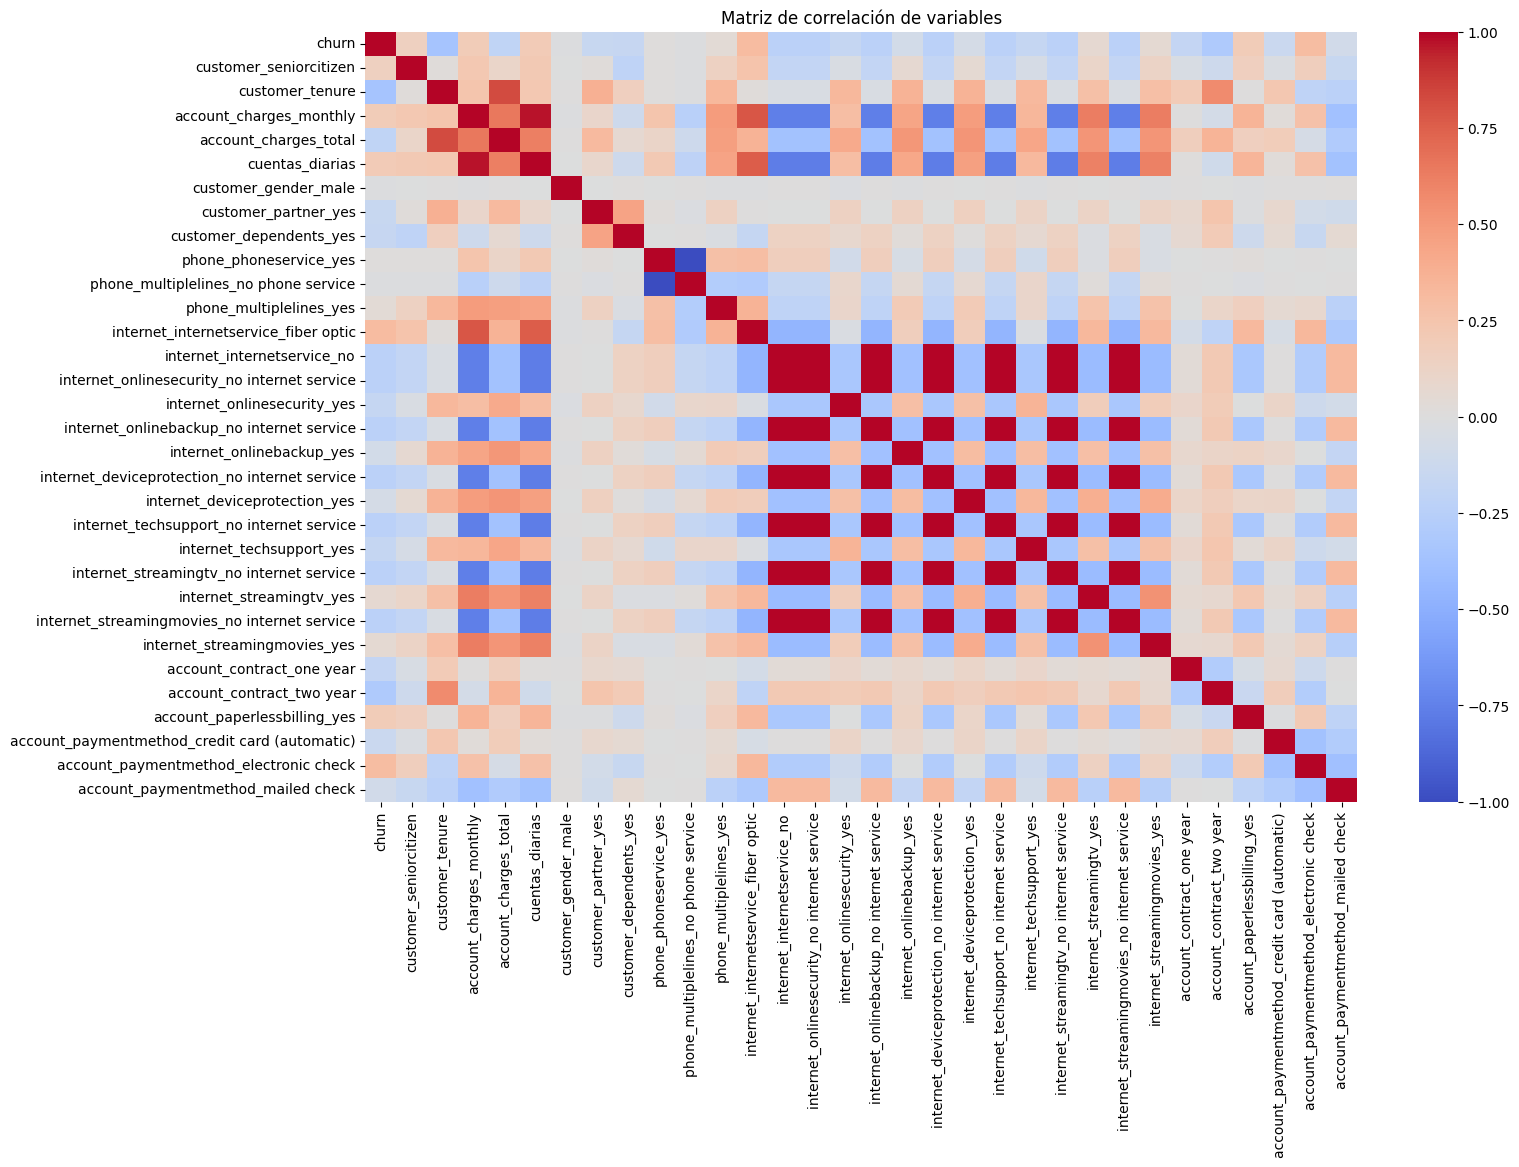

In [164]:
correlation_matrix = df.corr()
plt.figure(figsize=(16,10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación de variables")
plt.show()

In [165]:
df.corr()["churn"].sort_values(ascending=False)

,churn
churn,1.000000
internet_internetservice_fiber optic,0.307463
account_paymentmethod_electronic check,0.301455
cuentas_diarias,0.195594
account_charges_monthly,0.192922
account_paperlessbilling_yes,0.191454
customer_seniorcitizen,0.150541
internet_streamingtv_yes,0.063254
internet_streamingmovies_yes,0.060860
phone_multiplelines_yes,0.040033


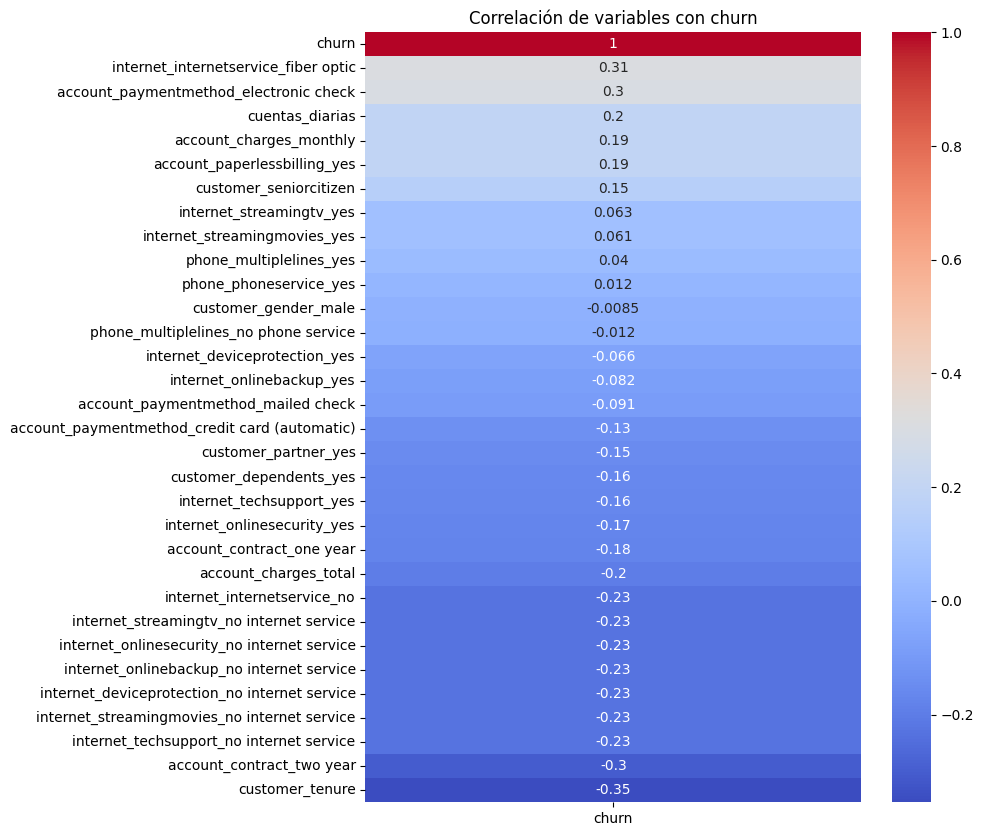

In [166]:
plt.figure(figsize=(8,10))
sns.heatmap(df.corr()[["churn"]].sort_values(by="churn", ascending=False),
            annot=True,
            cmap="coolwarm")

plt.title("Correlación de variables con churn")
plt.show()

Se analizó la matriz de correlación entre las variables numéricas y la variable objetivo churn con el fin de identificar posibles relaciones relevantes para el modelo predictivo.

Los resultados muestran que variables como **customer_tenure** (-0.35) y **account_contract_two_year** (-0.30) presentan una correlación negativa moderada con la cancelación, lo que indica que los clientes con mayor tiempo en la empresa o con contratos más largos tienen menor probabilidad de cancelar el servicio.

Por otro lado, variables como **internet_internetservice_fiber_optic** (0.31) y **account_paymentmethod_electronic_check** (0.30) presentan correlación positiva con el churn, lo que sugiere que estos perfiles de clientes tienden a cancelar con mayor frecuencia.

# Análisis Dirigido

variables específicas que se relacionan con la cancelación

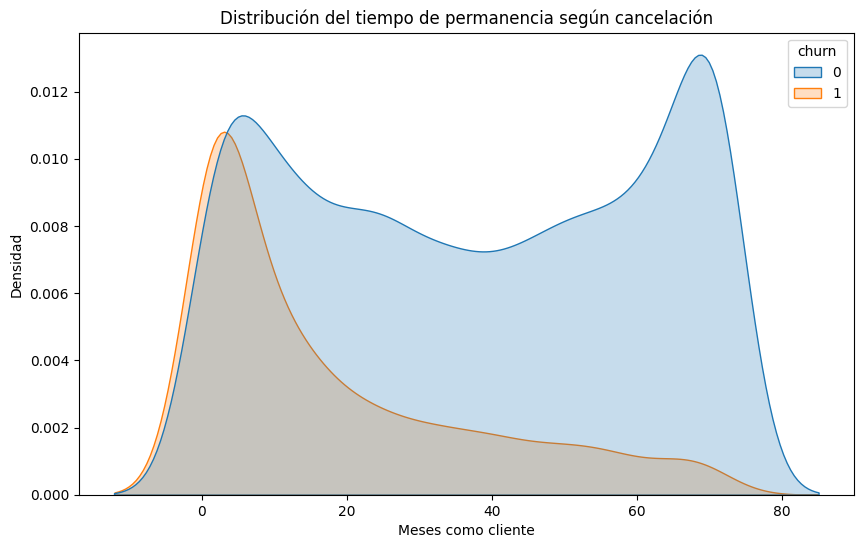

In [167]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="customer_tenure",
    hue="churn",
    fill=True,
)

plt.title("Distribución del tiempo de permanencia según cancelación")
plt.xlabel("Meses como cliente")
plt.ylabel("Densidad")

plt.show()



Vemos que los clientes que cancelaron el servicio presentan, en promedio, un menor tiempo de permanencia en la empresa en comparación con los clientes que continúan activos. Esto sugiere que la probabilidad de cancelación es mayor durante las primeras etapas de la relación con el cliente.

### Relación entre el Servicio de Internet (Fibra Óptica) y la Cancelación (`churn`)

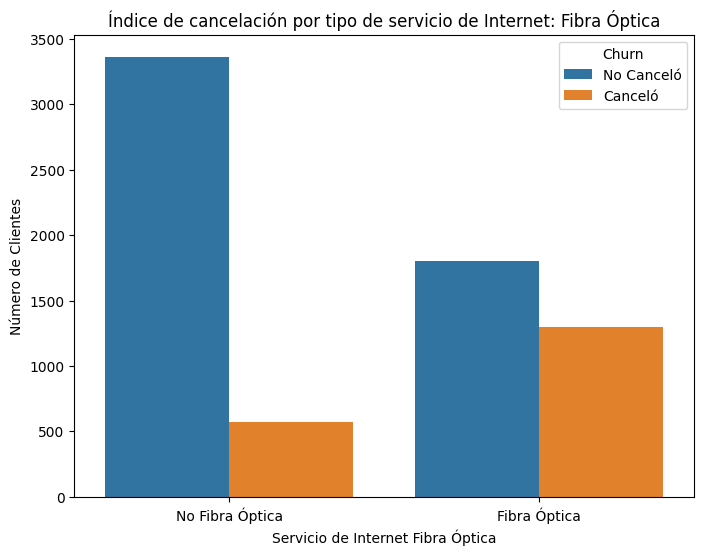

In [168]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="internet_internetservice_fiber optic", hue="churn")
plt.title("Índice de cancelación por tipo de servicio de Internet: Fibra Óptica")
plt.xlabel("Servicio de Internet Fibra Óptica")
plt.ylabel("Número de Clientes")
plt.xticks(ticks=[0, 1], labels=["No Fibra Óptica", "Fibra Óptica"])
plt.legend(title="Churn", labels=["No Canceló", "Canceló"])

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")

plt.show()

### Relación entre el Método de Pago (Cheque Electrónico) y la Cancelación (`churn`)

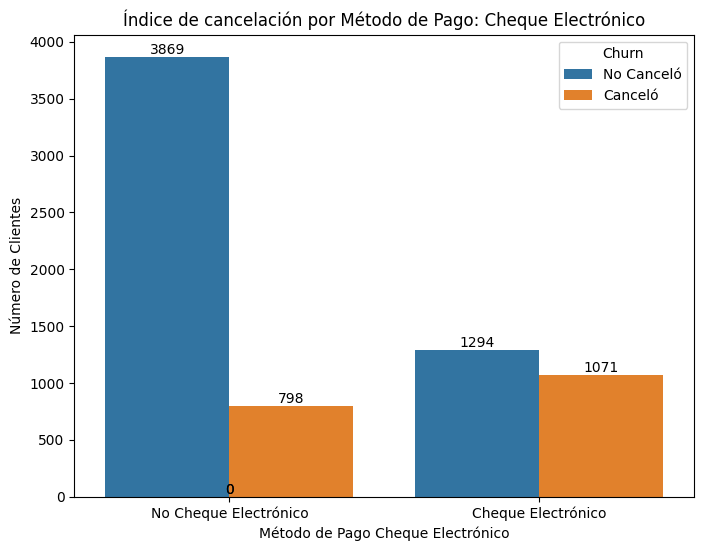

In [169]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x="account_paymentmethod_electronic check", hue="churn")
plt.title("Índice de cancelación por Método de Pago: Cheque Electrónico")
plt.xlabel("Método de Pago Cheque Electrónico")
plt.ylabel("Número de Clientes")
plt.xticks(ticks=[0, 1], labels=["No Cheque Electrónico", "Cheque Electrónico"])
plt.legend(title="Churn", labels=["No Canceló", "Canceló"])

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")

plt.show()

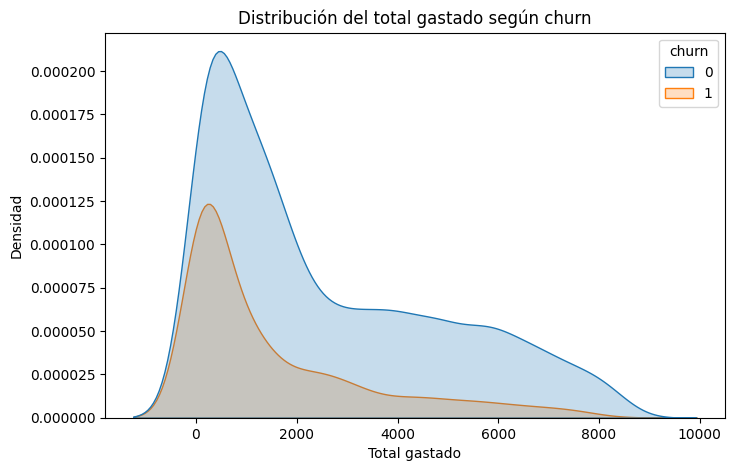

In [170]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="account_charges_total",
    hue="churn",
    fill=True
)

plt.title("Distribución del total gastado según churn")
plt.xlabel("Total gastado")
plt.ylabel("Densidad")

plt.show()

Vemos que los clientes que cancelan el servicio tienden a presentar un gasto total menor en comparación con los clientes que permanecen activos. Esto se relaciona con el tiempo de permanencia, ya que los clientes que cancelan suelen hacerlo en etapas tempranas del servicio.

# Creación de Modelos

Modelo con normalización: Regresión Logística

In [171]:
# Usamos X_train_scaled y X_test_scaled porque ya fueron estandarizados
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluación
print("Exactitu de la Regresión Logística:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))


Exactitu de la Regresión Logística: 0.7990521327014218
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1554
           1       0.63      0.56      0.60       556

    accuracy                           0.80      2110
   macro avg       0.74      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



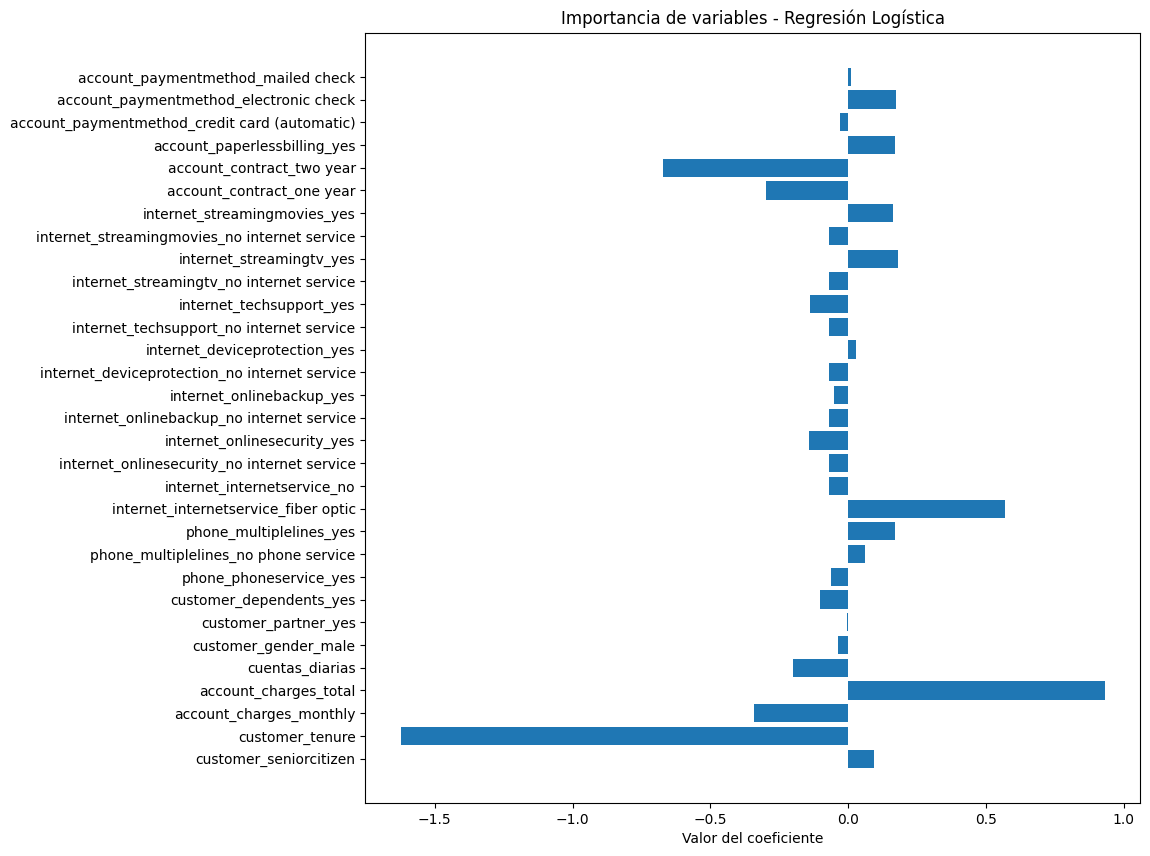

In [172]:
coef = logreg.coef_[0]
features = X.columns

plt.figure(figsize=(10,10))
plt.barh(features, coef)
plt.title("Importancia de variables - Regresión Logística")
plt.xlabel("Valor del coeficiente")
plt.show()

Se utiliza Regresión Logística porque es un modelo que predice la probabilidad de cancelación (churn) basado en las características de los clientes. Dado que este modelo es sensible a la escala de las variables, aplicar estandarización asegura que ninguna variable domine el cálculo de los coeficientes por tener valores más grandes.

Por ejemplo, variables como **account_charges_total** llegan hasta **8684**, mientras que **cuentas_diarias** apenas llega a **3**. Sin estandarización, la magnitud de estas variables podría sesgar el modelo. Al escalar los datos, todas las variables se ponen en la misma escala (media 0 y desviación estándar 1), lo que permite que la regresión logística interprete correctamente la relación entre cada variable y la probabilidad de churn, manteniendo la consistencia de los resultados.

Modelo sin normalización: Árbol de Decisión

In [173]:
# Usamos X_train y X_test sin escalar
tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

# Evaluación
print("Exactitud del Árbol de Decisión:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Exactitud del Árbol de Decisión: 0.7843601895734598
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1554
           1       0.63      0.45      0.52       556

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110



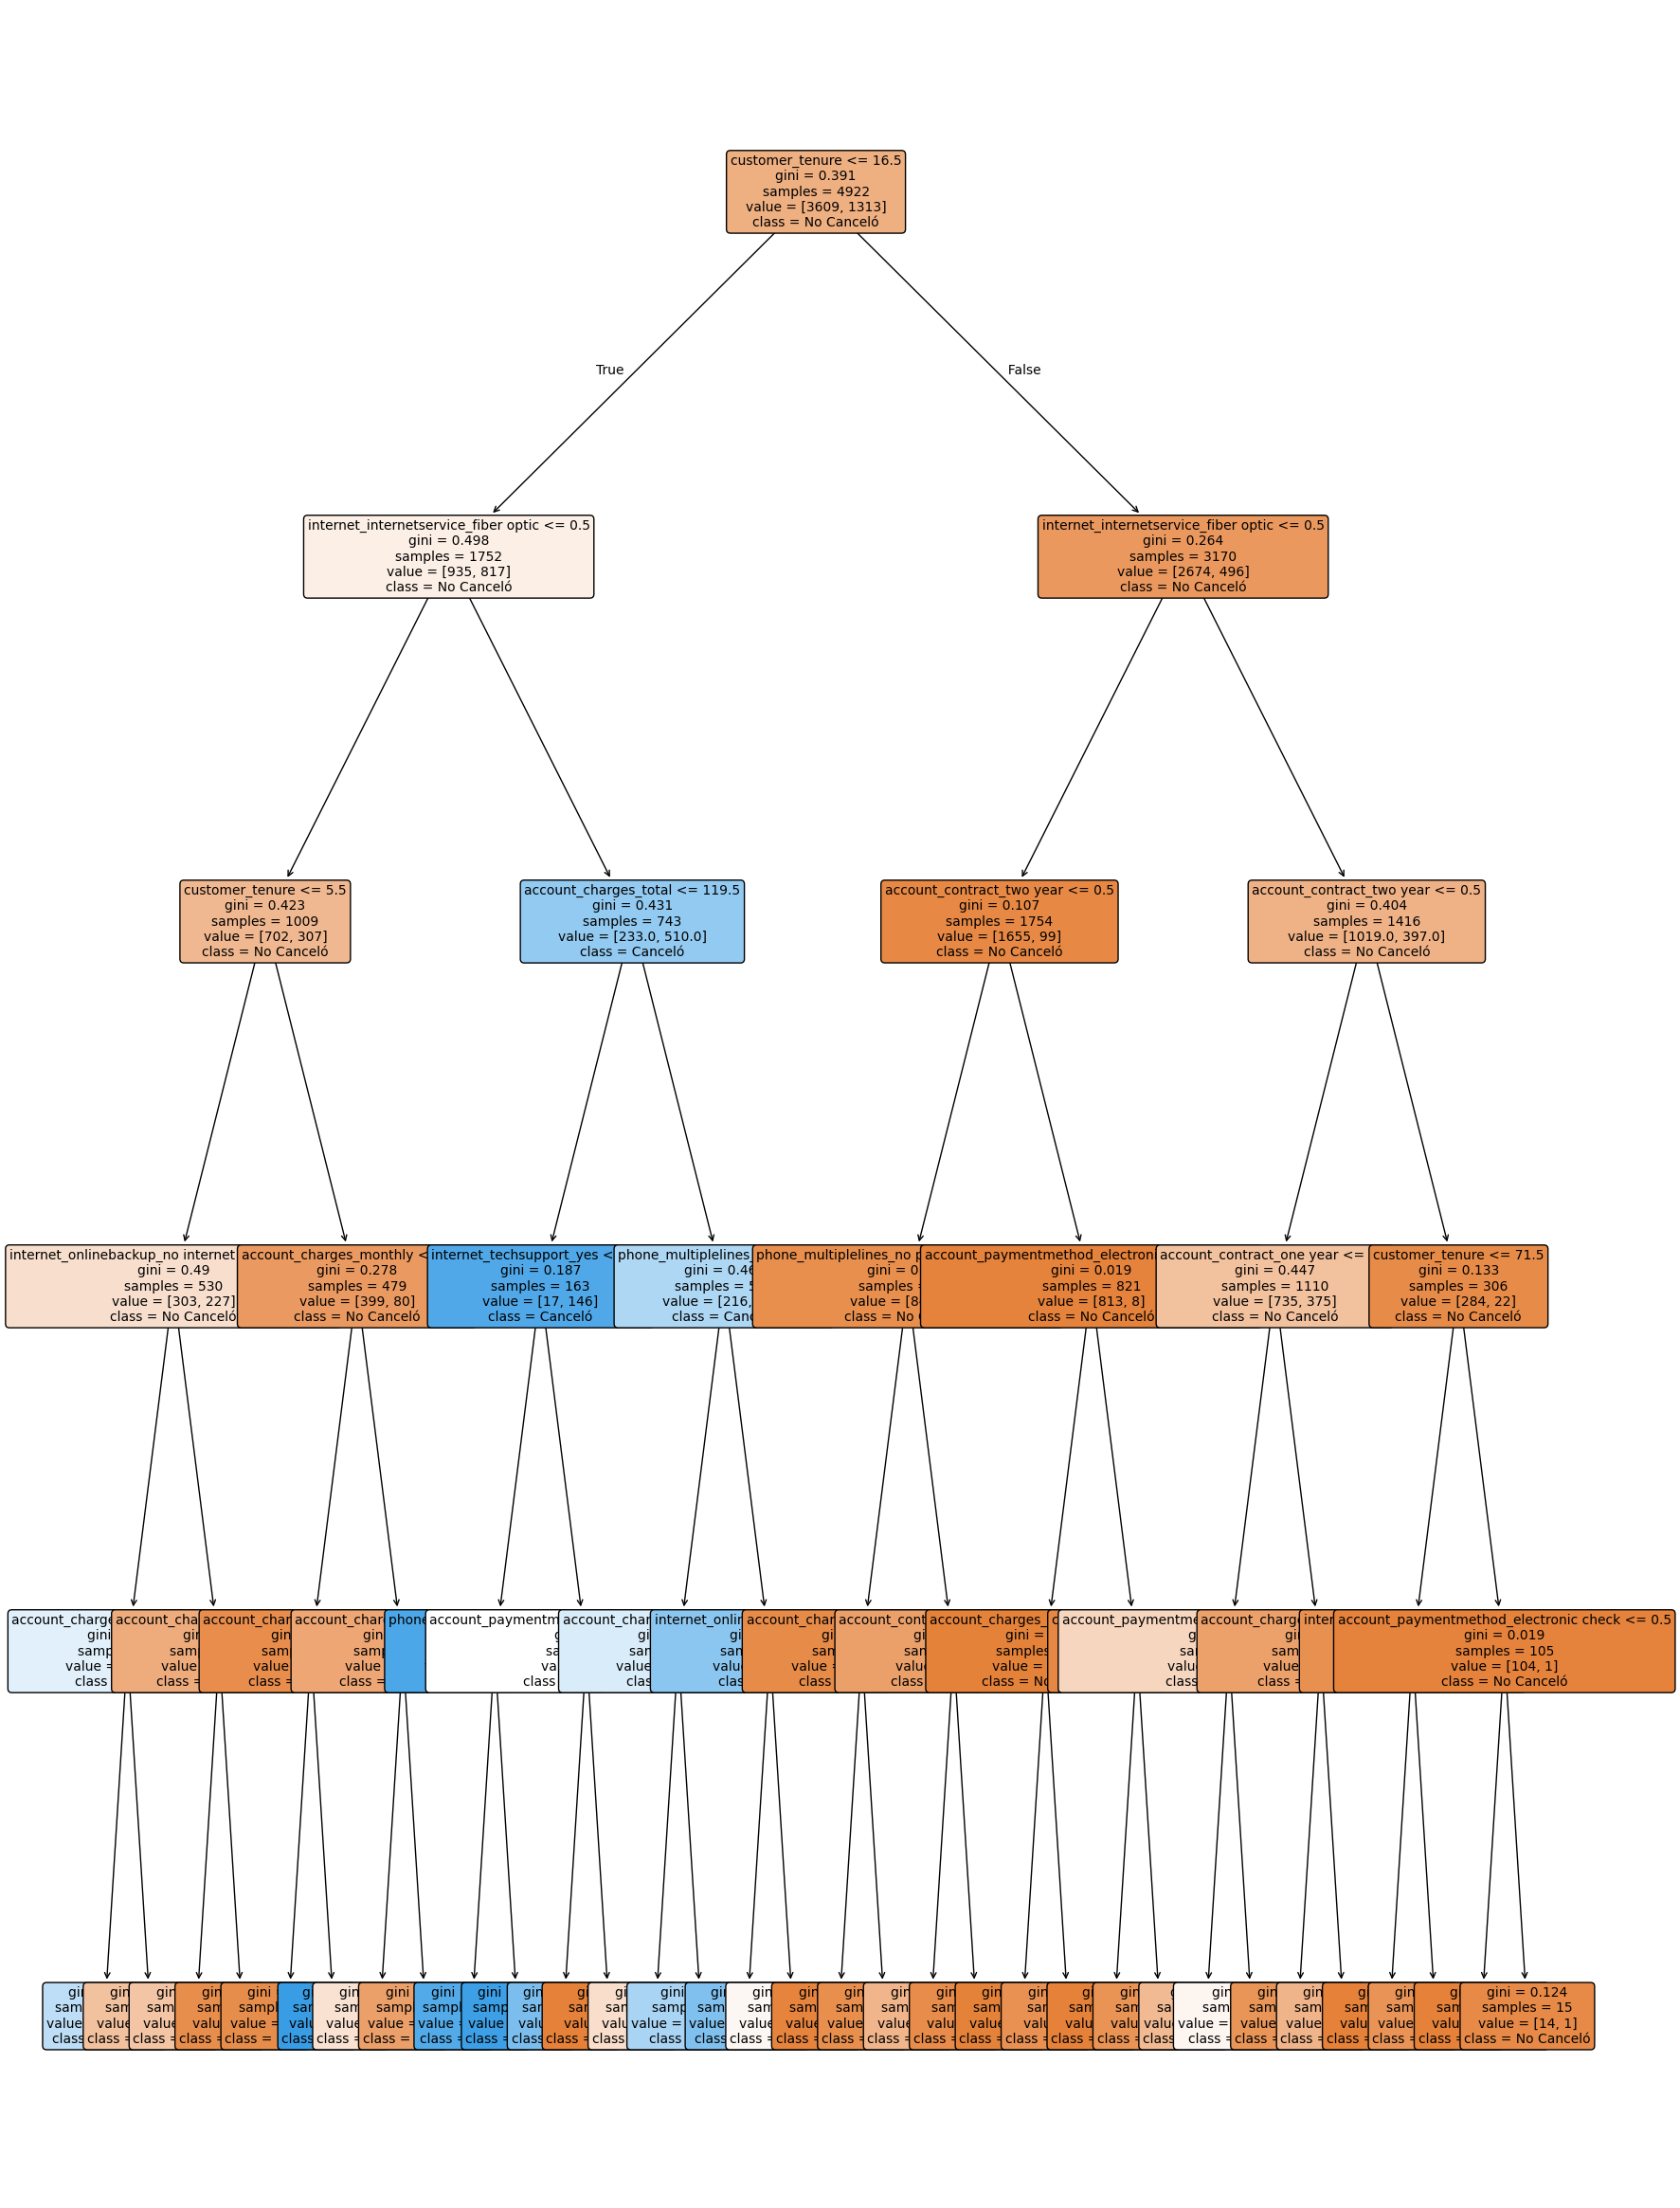

In [174]:
plt.figure(figsize=(20,30))
plot_tree(tree,
          feature_names=X.columns,
          class_names=["No Canceló", "Canceló"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()


Dado que los árboles de decisión no dependen de la escala de las variables, no es necesario aplicar estandarización; las comparaciones se hacen en función de los valores relativos, no de su magnitud. Por ejemplo, el árbol puede usar directamente **account_charges_total** (que va hasta 8684) y **cuentas_diarias** (que va hasta 3) para crear los nodos sin que una variable domine a la otra.

La ventaja de este modelo es que identifica de manera natural las variables más relevantes para la cancelación. Variables como **customer_tenure**, **account_contract_two_year** o **internet_internetservice_fiber optic** pueden aparecer en los primeros niveles del árbol, reflejando que son determinantes en la probabilidad de **churn**.

# Evaluación de los Modelos

--- Regresión Logística ---
Accuracy: 0.7990521327014218
Precision: 0.6336032388663968
Recall: 0.5629496402877698
F1-score: 0.5961904761904762


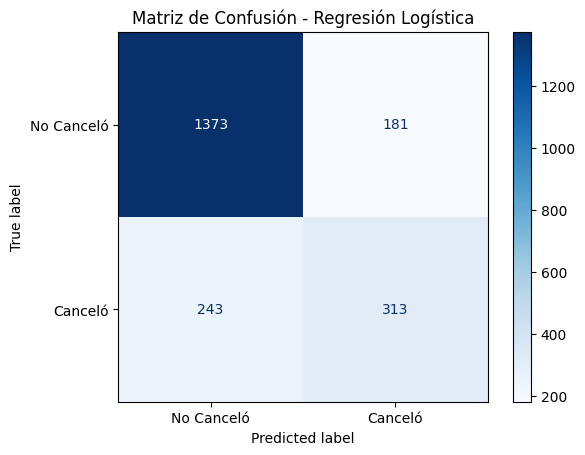

--- Árbol de Decisión ---
Accuracy: 0.7843601895734598
Precision: 0.6265664160401002
Recall: 0.44964028776978415
F1-score: 0.5235602094240838


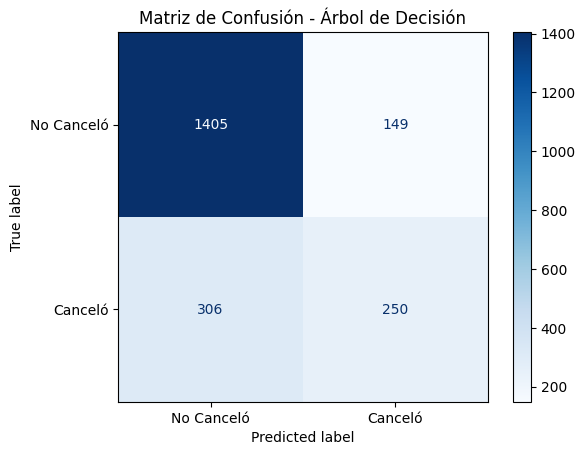

In [175]:
# Función para evaluar un modelo
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)

    print(f"--- {nombre_modelo} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Canceló","Canceló"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión - {nombre_modelo}")
    plt.show()

# Evaluar Regresión Logística
evaluar_modelo(logreg, X_test_scaled, y_test, "Regresión Logística")

# Evaluar Árbol de Decisión
evaluar_modelo(tree, X_test, y_test, "Árbol de Decisión")

Análisis y Comparación de Modelos
1. Regresión Logística (con estandarización):

Accuracy: 0.799 (aproximadamente 80% de aciertos generales).
Precision (Clase 1 - Canceló): 0.633. De todos los clientes que el modelo predijo que cancelarían, el 63.3% realmente lo hizo.
Recall (Clase 1 - Canceló): 0.563. De todos los clientes que realmente cancelaron, el modelo identificó correctamente al 56.3%.
F1-score (Clase 1 - Canceló): 0.596. Un equilibrio entre precisión y recall para la clase minoritaria.
Matriz de Confusión: La matriz de confusión (no incluida en el texto, pero generada por el código) nos mostraría el desglose de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.
2. Árbol de Decisión (sin estandarización, max_depth=5):

Accuracy: 0.784 (aproximadamente 78.4% de aciertos generales).
Precision (Clase 1 - Canceló): 0.626. De todos los clientes que el modelo predijo que cancelarían, el 62.6% realmente lo hizo.
Recall (Clase 1 - Canceló): 0.450. De todos los clientes que realmente cancelaron, el modelo identificó correctamente solo al 45%.
F1-score (Clase 1 - Canceló): 0.523. Un F1-score inferior, indicando un peor equilibrio entre precisión y recall para la clase minoritaria.
Matriz de Confusión: Similarmente, esta matriz nos daría un desglose visual de los resultados.

**¿Cuál modelo tuvo el mejor desempeño?**

Considerando las métricas, la Regresión Logística tuvo un mejor desempeño general para la detección de churn:

Mayor Accuracy: La Regresión Logística es ligeramente más precisa en general (80% vs 78.4%).
Mejor Recall para churn (Clase 1): Este es un punto crítico. La Regresión Logística fue capaz de identificar a más clientes que realmente cancelarían (56.3% vs 45%). En problemas de detección de churn, a menudo es preferible tener un buen recall para poder intervenir con los clientes en riesgo.
Mejor F1-score para churn (Clase 1): El F1-score de la Regresión Logística (0.596) es notablemente superior al del Árbol de Decisión (0.523) para la clase churn, lo que indica un mejor balance general en la identificación de clientes que cancelan.
Aunque la precisión es similar, la capacidad de la Regresión Logística para capturar más casos de churn es una ventaja en este contexto.

**¿Algún modelo presentó overfitting o underfitting?**

Con la información actual (solo las métricas del conjunto de prueba), es difícil determinar con total certeza si hay overfitting o underfitting. Sin embargo, podemos hacer algunas inferencias:

Regresión Logística: El modelo muestra un rendimiento razonable en el conjunto de prueba. Un accuracy del 80% y un F1-score decente para la clase minoritaria sugieren que no hay un underfitting severo. Para evaluar overfitting, necesitaríamos ver las métricas en el conjunto de entrenamiento. Si las métricas de entrenamiento fueran significativamente más altas, podría indicar un ligero overfitting, pero el max_iter=1000 y la estandarización suelen ayudar a mitigar esto.

Árbol de Decisión: El Árbol de Decisión con max_depth=5 parece haber sido un buen intento para evitar el overfitting que suele ocurrir en árboles muy profundos. Sin embargo, el Recall para la clase churn (0.45) es relativamente bajo en comparación con la Regresión Logística. Esto podría sugerir un ligero underfitting para la clase minoritaria, es decir, el árbol no está capturando suficientemente bien los patrones complejos que llevan al churn. Un max_depth de 5 podría ser demasiado restrictivo y el modelo podría ser un poco demasiado simple para aprender todas las relaciones en los datos. No parece haber overfitting severo dado el rendimiento, pero un bajo recall en la clase de interés puede ser una señal de que el modelo no está aprendiendo lo suficiente.

# Análisis de la Importancia de las Variables

**Regresión Logística**

Las variables importantes se identifican a través de los coeficientes del modelo:

Coeficiente positivo → aumenta la probabilidad de churn.

Coeficiente negativo → reduce la probabilidad de churn.

variables como customer_tenure, account_contract_two_year o internet_internetservice_fiber optic pueden ser determinantes, según el signo y magnitud de su coeficiente.

**Árbol de Decisión**
La importancia se basa en cómo cada variable contribuye a reducir la impureza en los nodos del árbol:

Valores más altos → variables más relevantes para separar churn/no churn.

Permite visualizar qué características son más influyentes en las decisiones del árbol, por ejemplo, customer_tenure o account_charges_total.

# Conclusión

Tras la exploración y modelado del dataset de clientes, se elaboró un informe completo para entender los factores que más influyen en la cancelación (**churn**) y proponer estrategias de retención.

**1️⃣ Factores clave identificados**

A partir de los modelos implementados (Regresión Logística y Árbol de Decisión), se destacan las siguientes variables como las más determinantes en la predicción de cancelación:

Tiempo de permanencia (**customer_tenure**): Los clientes con menor antigüedad presentan mayor probabilidad de cancelar el servicio.

Tipo de contrato (**account_contract_two_year**, **account_contract_one_year**): Los clientes con contratos más largos tienen menor churn, indicando que fidelizar mediante contratos extendidos es efectivo.

Método de pago (**account_paymentmethod_electronic check**): Los clientes que usan cheque electrónico muestran mayor tendencia a cancelar.

Tipo de servicio de internet (**internet_internetservice_fiber optic**): La fibra óptica se asoció con un mayor churn, posiblemente reflejando expectativas de servicio o costos percibidos.

Gasto total (**account_charges_total**): Los clientes con menor consumo total tienden a cancelar antes, lo que refleja relación entre compromiso y valor percibido.


**2️⃣ Comparación de modelos**

Regresión Logística (con escalado):

*   Permite interpretar la influencia de cada variable mediante coeficientes.
*   Destaca claramente los factores positivos y negativos que afectan el churn.
*   Buen desempeño global, especialmente para detectar patrones generales de cancelación.


Árbol de Decisión (sin escalado):


*   Identifica las variables más importantes de manera jerárquica y visual.
*   Permite entender cómo se combinan múltiples factores para clasificar clientes.

*   Puede mostrar signos de overfitting si el árbol es demasiado profundo, pero con control de profundidad mantiene buen balance entre precisión y generalización.











**3️⃣ Estrategias de retención sugeridas**

Con base en los resultados obtenidos, se proponen las siguientes estrategias:


1.   Fidelización temprana: Incentivar a los clientes nuevos para que se comprometan con contratos de mayor duración o planes escalonados que aumenten su permanencia.
2.   Optimización del método de pago: Promover métodos de pago más seguros o cómodos para reducir el riesgo de churn asociado a cheques electrónicos.
3.  Segmentación del servicio de internet: Analizar los factores que generan insatisfacción en clientes de fibra óptica y ofrecer mejoras, bundles o beneficios exclusivos.
4.  Programas de engagement: Incentivar a los clientes de menor gasto total con promociones, paquetes o programas de lealtad que aumenten su valor percibido.


**Síntesis Final**

El análisis confirma que el churn está influenciado por factores combinados de tiempo de permanencia, tipo de contrato, método de pago, servicio y consumo total.

La Regresión Logística permite interpretar la contribución de cada variable.

El Árbol de Decisión ofrece claridad sobre interacciones y jerarquía de variables.

Ambas herramientas juntas proporcionan un panorama completo para tomar decisiones estratégicas y reducir la cancelación de clientes.